In [2]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

In [3]:
# Path to experiment directory
EXPERIMENT_DIR = Path("experiments/exp1")

# Run labels and descriptions
RUN_INFO = {
    "A": {"label": "GPipe (no interf)", "color": "#2196f3"},
    "B": {"label": "Shisha (no interf)", "color": "#4caf50"},
    "C": {"label": "GPipe (interf)", "color": "#f44336"},
    "D": {"label": "Exhaustive (interf)", "color": "#ff9800"},
    "E": {"label": "Shisha (interf)", "color": "#9c27b0"},
}

In [6]:
# Load all available runs
runs = {}
for run_id in ["A", "B", "C", "D", "E"]:
    path = EXPERIMENT_DIR / f"run_{run_id}.json"
    if path.exists():
        with open(path) as f:
            runs[run_id] = json.load(f)
        print(f"Loaded run {run_id}: {path.name}")
    else:
        print(f"Missing run {run_id}: {path.name}")

# Load experiment metadata
meta_path = EXPERIMENT_DIR / "experiment_meta.json"
if meta_path.exists():
    with open(meta_path) as f:
        experiment_meta = json.load(f)
    print(f"\nExperiment: {experiment_meta}")

# Collect all model names across runs
all_models = set()
for data in runs.values():
    all_models.update(data.get("results", {}).keys())
all_models = sorted(all_models)
print(f"Models: {all_models}")

Loaded run A: run_A.json
Loaded run B: run_B.json
Loaded run C: run_C.json
Loaded run D: run_D.json
Loaded run E: run_E.json

Experiment: {'timestamp': '2026-04-03_12-28-10', 'repetition': 1, 'total_repetitions': 1, 'model_set': 'reduced', 'num_requests': 5000, 'schedule': 'gradient', 'interference_seed': 1912795924, 'nproc': 4, 'omp_threads': 8, 'skipped': []}
Models: ['conv_next', 'efficientnet_b6']


## Run Summary

In [7]:
for run_id, data in sorted(runs.items()):
    info = RUN_INFO.get(run_id, {})
    meta = data.get("meta", {})
    optimizer = meta.get("optimizer", "?")
    print(f"=== Run {run_id}: {info.get('label', '?')} ===")
    print(f"  Optimizer: {optimizer}")
    for model in all_models:
        result = data.get("results", {}).get(model)
        if result is None:
            print(f"  {model}: N/A")
            continue
        batches = result.get("batches", [])
        rps = result.get("requests_per_second", 0)
        timed = [b for b in batches if "timing" in b]
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        if timed:
            times = [b["timing"]["end"] - b["timing"]["start"] for b in timed]
            print(f"  {model}: rps={rps:.2f}, batches={len(timed)}, rebalances={rebalances}, "
                  f"at_optimum={at_optimum}, avg_fwd={np.mean(times):.3f}s")
        else:
            print(f"  {model}: rps={rps:.2f}, no timing data")
    print()

=== Run A: GPipe (no interf) ===
  Optimizer: StaticGPipeOptimizer
  conv_next: rps=21.92, batches=100, rebalances=0, at_optimum=0, avg_fwd=1.089s
  efficientnet_b6: rps=4.18, batches=100, rebalances=0, at_optimum=0, avg_fwd=5.824s

=== Run B: Shisha (no interf) ===
  Optimizer: TimeBasedShishaPipelineOptimizer
  conv_next: rps=26.90, batches=5000, rebalances=1216, at_optimum=3848, avg_fwd=0.806s
  efficientnet_b6: rps=5.00, batches=5000, rebalances=3136, at_optimum=1992, avg_fwd=4.389s

=== Run C: GPipe (interf) ===
  Optimizer: TimeBasedShishaPipelineOptimizer
  conv_next: rps=27.28, batches=16192, rebalances=0, at_optimum=0, avg_fwd=1.113s
  efficientnet_b6: rps=4.95, batches=5920, rebalances=0, at_optimum=0, avg_fwd=6.286s

=== Run D: Exhaustive (interf) ===
  Optimizer: TimeBasedShishaPipelineOptimizer
  conv_next: rps=33.01, batches=23712, rebalances=1056, at_optimum=20576, avg_fwd=0.844s
  efficientnet_b6: rps=6.39, batches=9536, rebalances=1120, at_optimum=6208, avg_fwd=4.459s


## Throughput Comparison (RPS)

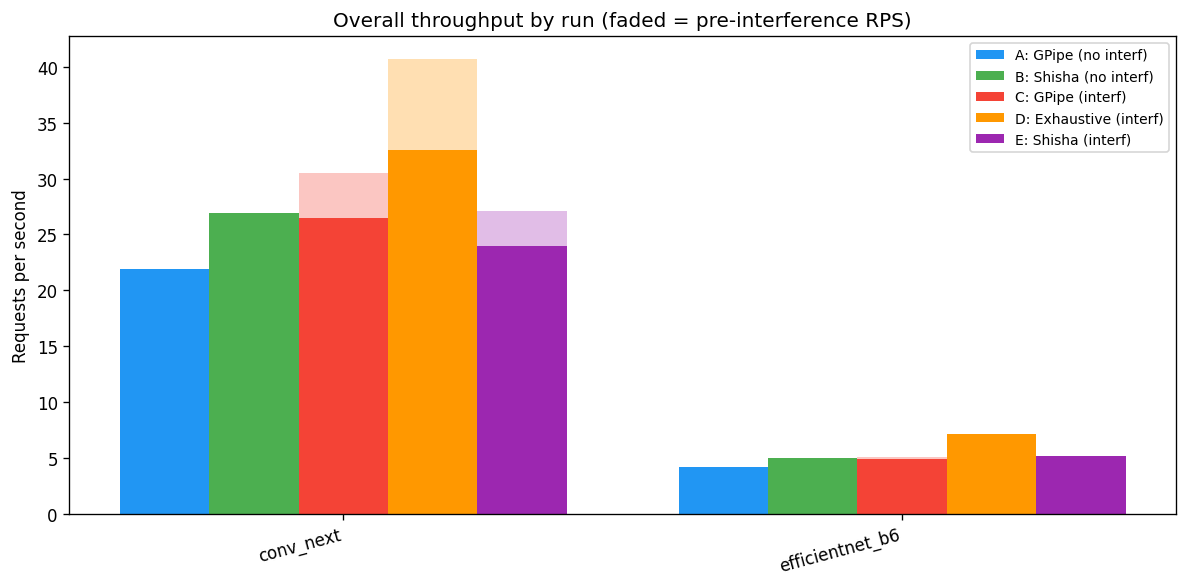

In [8]:
run_ids = sorted(runs.keys())
n_runs = len(run_ids)
n_models = len(all_models)

def _get_model_schedule(data, model):
    """Get schedule_steps and step_duration for a model."""
    meta = data.get("meta", {})
    ms = meta.get("model_schedules", {})
    if model in ms:
        return ms[model].get("schedule_steps", []), ms[model].get("step_duration", 0)
    if "all" in ms:
        return ms["all"].get("schedule_steps", []), ms["all"].get("step_duration", 0)
    return meta.get("schedule_steps", []), meta.get("step_duration", 0)

def _compute_step_rps(data, model):
    """Compute per-step RPS for interference runs. Returns (idle_rps, interf_rps)."""
    result = data.get("results", {}).get(model)
    if result is None:
        return 0, 0
    interf_log = data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    schedule_steps, step_duration = _get_model_schedule(data, model)

    if not events or not step_duration or not schedule_steps:
        return result.get("requests_per_second", 0), 0

    # Find first event time (skip config/seed entries)
    first_time = None
    for e in events:
        if "time" in e and "event" in e:
            first_time = e["time"]
            break
    if first_time is None:
        return result.get("requests_per_second", 0), 0

    timed = [b for b in result.get("batches", []) if "timing" in b]
    if len(timed) < 2:
        return 0, 0

    # Step 0 = idle (pre-interference)
    r0_start = first_time
    r0_end = first_time + step_duration
    idle_batches = [b for b in timed if r0_start <= b["timing"]["start"] < r0_end]
    if len(idle_batches) >= 2:
        wall = idle_batches[-1]["timing"]["end"] - idle_batches[0]["timing"]["start"]
        idle_rps = len(idle_batches) / wall if wall > 0 else 0
    else:
        idle_rps = 0

    # Steps 1+ = interference
    r1_start = first_time + step_duration
    interf_batches = [b for b in timed if b["timing"]["start"] >= r1_start]
    if len(interf_batches) >= 2:
        wall = interf_batches[-1]["timing"]["end"] - interf_batches[0]["timing"]["start"]
        interf_rps = len(interf_batches) / wall if wall > 0 else 0
    else:
        interf_rps = 0

    return idle_rps, interf_rps

fig, ax = plt.subplots(figsize=(max(10, n_models * 2.5), 5))

x = np.arange(n_models)
bar_width = 0.8 / n_runs

for i, run_id in enumerate(run_ids):
    info = RUN_INFO.get(run_id, {})
    color = info.get("color", "gray")
    offset = (i - n_runs / 2 + 0.5) * bar_width
    has_interference = run_id in ("C", "D", "E")

    for j, model in enumerate(all_models):
        if has_interference and run_id in runs:
            idle_rps, interf_rps = _compute_step_rps(runs[run_id], model)
            # Solid bar: interference RPS
            ax.bar(x[j] + offset, interf_rps, bar_width, color=color, alpha=1.0,
                   label=f"{run_id}: {info.get('label', '?')}" if j == 0 else None)
            # Faded bar on top: pre-interference portion
            if idle_rps > interf_rps:
                ax.bar(x[j] + offset, idle_rps - interf_rps, bar_width,
                       bottom=interf_rps, color=color, alpha=0.3)
        else:
            result = runs.get(run_id, {}).get("results", {}).get(model)
            rps = result["requests_per_second"] if result else 0
            ax.bar(x[j] + offset, rps, bar_width, color=color, alpha=1.0,
                   label=f"{run_id}: {info.get('label', '?')}" if j == 0 else None)

ax.set_xticks(x)
ax.set_xticklabels(all_models, rotation=15, ha="right")
ax.set_ylabel("Requests per second")
ax.set_title("Overall throughput by run (faded = pre-interference RPS)")
ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## Throughput Impact Table

In [18]:
# Show RPS and % relative to run A (GPipe baseline)
baseline_id = "A"

header = f"{'Model':<20}"
for run_id in run_ids:
    info = RUN_INFO.get(run_id, {})
    header += f"{run_id + ': ' + info.get('label', '?'):>25}"
print(header)
print("-" * len(header))

for model in all_models:
    bl_result = runs.get(baseline_id, {}).get("results", {}).get(model)
    bl_rps = bl_result["requests_per_second"] if bl_result else 0

    row = f"{model:<20}"
    for run_id in run_ids:
        result = runs[run_id].get("results", {}).get(model)
        if result:
            rps = result["requests_per_second"]
            if bl_rps > 0:
                pct = (rps / bl_rps) * 100
                row += f"{rps:>12.2f} ({pct:>5.0f}%)"
            else:
                row += f"{rps:>12.2f}       "
        else:
            row += f"{'N/A':>25}"
    print(row)

Model                    A: GPipe (no interf)    B: Shisha (no interf)        C: GPipe (interf)   D: Exhaustive (interf)       E: Shisha (interf)
-------------------------------------------------------------------------------------------------------------------------------------------------
conv_next                  21.92 (  100%)       26.90 (  123%)       27.28 (  124%)       33.01 (  151%)       24.59 (  112%)
efficientnet_b6             4.18 (  100%)        5.00 (  120%)        4.95 (  118%)        6.39 (  153%)        5.07 (  121%)


## Batch Times — All Runs

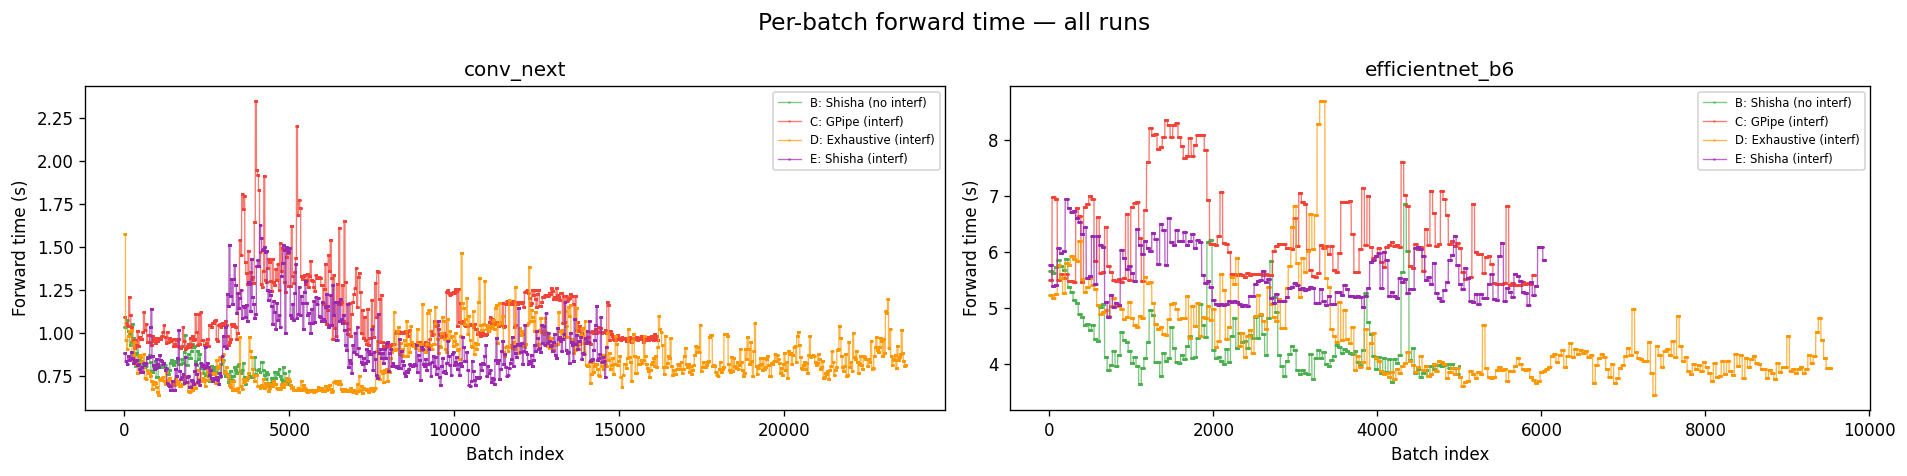

In [10]:
n_models = len(all_models)
cols = min(n_models, 2)
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 4 * rows), squeeze=False)

for idx, model in enumerate(all_models):
    ax = axes[idx // cols][idx % cols]

    for run_id in run_ids:
        if run_id == 'A':
            continue

        result = runs[run_id].get("results", {}).get(model)
        if result is None:
            continue
        batches = result.get("batches", [])
        timed = [b for b in batches if "timing" in b]
        elapsed = [b["timing"]["end"] - b["timing"]["start"] for b in timed]
        if not elapsed:
            continue

        info = RUN_INFO.get(run_id, {})
        ax.plot(range(len(elapsed)), elapsed,
                color=info.get("color", "gray"), alpha=0.7,
                label=f"{run_id}: {info.get('label', '?')}",
                marker=".", markersize=1, linewidth=0.8)

    ax.set_title(model)
    ax.set_xlabel("Batch index")
    ax.set_ylabel("Forward time (s)")
    ax.legend(fontsize="x-small", loc="upper right")

for idx in range(n_models, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)

fig.suptitle("Per-batch forward time — all runs", fontsize=14)
fig.tight_layout()
plt.show()

## Batch Times — No Interference (A vs B)

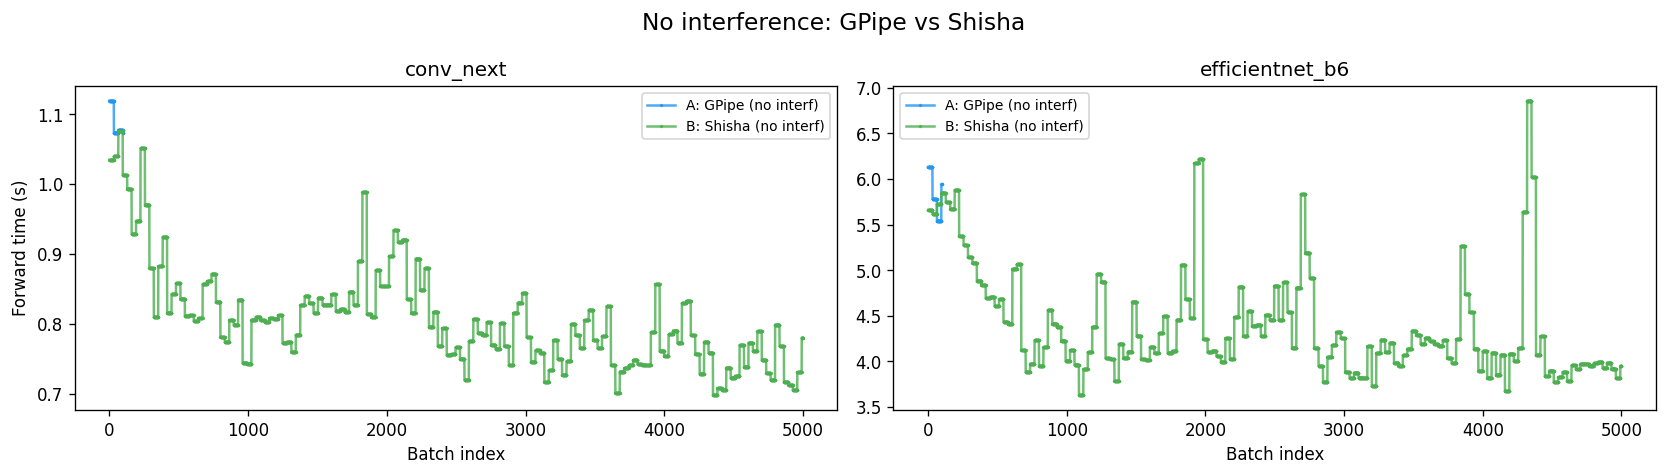

In [12]:
no_interf_runs = {k: v for k, v in runs.items() if k in ("A", "B")}
if no_interf_runs:
    fig, axes = plt.subplots(1, len(all_models), figsize=(7 * len(all_models), 4), squeeze=False)

    for idx, model in enumerate(all_models):
        ax = axes[0][idx]
        for run_id, data in sorted(no_interf_runs.items()):
            result = data.get("results", {}).get(model)
            if result is None:
                continue
            timed = [b for b in result.get("batches", []) if "timing" in b]
            elapsed = [b["timing"]["end"] - b["timing"]["start"] for b in timed]
            if not elapsed:
                continue
            info = RUN_INFO.get(run_id, {})
            ax.plot(range(len(elapsed)), elapsed,
                    color=info.get("color", "gray"), alpha=0.8,
                    label=f"{run_id}: {info.get('label', '?')}",
                    marker=".", markersize=2)
        ax.set_title(model)
        ax.set_xlabel("Batch index")
        ax.set_ylabel("Forward time (s)" if idx == 0 else "")
        ax.legend(fontsize="small")

    fig.suptitle("No interference: GPipe vs Shisha", fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("Runs A and B not available")

## Batch Times — Interference (C vs D vs E)

In [ ]:
def _find_first_interference_time(data, model):
    """Find the timestamp of the first non-idle interference event for a model."""
    interf_log = data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    for e in events:
        if e.get("event") == "start" and e.get("benchmark") not in ("idle", "random", None):
            return e["time"]
    return None

def _get_interference_periods(data, model):
    """Build a list of (t_start, t_end, label) for each interference step, relative to first interference."""
    first_interf = _find_first_interference_time(data, model)
    if first_interf is None:
        return []

    ms = data.get("meta", {}).get("model_schedules", {})
    sched = ms.get(model, ms.get("all", {}))
    steps = sched.get("schedule_steps", [])
    step_dur = sched.get("step_duration", 0)

    interf_log = data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    step_order = None
    for e in events:
        if "step_order" in e:
            step_order = e["step_order"]
            break
    if step_order is None or not steps or not step_dur:
        return []

    periods = []
    for i, step_idx in enumerate(step_order):
        t_start = (i - 1) * step_dur  # step_order[0] is idle at t=-step_dur
        if i == 0:
            continue  # skip idle
        t_end = t_start + step_dur
        step_def = steps[step_idx] if step_idx < len(steps) else []
        if not step_def:
            label = "idle"
        else:
            parts = []
            for bench in step_def:
                name, threads = bench[0], bench[1]
                short = "CPU" if "cpu" in name else "MEM" if "memory" in name else name
                parts.append(f"{short}×{threads}")
            label = " + ".join(parts)
        periods.append((t_start, t_end, label))
    return periods

def _count_threads(label):
    """Count total threads from a label like 'CPU×8 + MEM×1'."""
    if label == "idle":
        return 0
    total = 0
    for part in label.split(" + "):
        if "×" in part:
            try:
                total += int(part.split("×")[1])
            except ValueError:
                total += 1
    return total

# Build intensity colormap from actual step thread counts
_INTERF_CMAP = plt.cm.Oranges

def _get_interf_color(label, all_periods):
    """Map interference label to a color based on relative intensity across all periods."""
    threads = _count_threads(label)
    if threads == 0:
        return "#ffffff"
    # Get the range of thread counts across all non-idle periods
    all_threads = [_count_threads(l) for _, _, l in all_periods if _count_threads(l) > 0]
    if not all_threads:
        return "#ffffff"
    lo, hi = min(all_threads), max(all_threads)
    if lo == hi:
        norm = 0.5
    else:
        norm = (threads - lo) / (hi - lo)
    # Map to 0.15–0.55 range of the colormap (avoid too faint or too dark)
    return _INTERF_CMAP(0.15 + norm * 0.4)

interf_runs = {k: v for k, v in runs.items() if k in ("C", "D", "E")}
if interf_runs:
    fig, axes = plt.subplots(1, len(all_models), figsize=(7 * len(all_models), 4), squeeze=False)

    for idx, model in enumerate(all_models):
        ax = axes[0][idx]

        # Draw interference periods (same across runs — use first available)
        ref_data = next(iter(interf_runs.values()))
        periods = _get_interference_periods(ref_data, model)
        for t_start, t_end, label in periods:
            color = _get_interf_color(label, periods)
            ax.axvspan(t_start, t_end, color=color, alpha=0.6, zorder=0)
            ax.text((t_start + t_end) / 2, 1.0, label, transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=5, color="gray", rotation=0)

        for run_id, data in sorted(interf_runs.items()):
            result = data.get("results", {}).get(model)
            if result is None:
                continue
            timed = [b for b in result.get("batches", []) if "timing" in b]
            if not timed:
                continue

            first_interf = _find_first_interference_time(data, model)
            if first_interf is None:
                continue

            t_since_interf = [b["timing"]["start"] - first_interf for b in timed]
            elapsed = [b["timing"]["end"] - b["timing"]["start"] for b in timed]

            info = RUN_INFO.get(run_id, {})
            ax.plot(t_since_interf, elapsed,
                    color=info.get("color", "gray"), alpha=0.8,
                    label=f"{run_id}: {info.get('label', '?')}",
                    marker=".", markersize=1, linewidth=0.8)

        # Run A mean as baseline
        if "A" in runs:
            a_result = runs["A"].get("results", {}).get(model)
            if a_result:
                a_timed = [b for b in a_result.get("batches", []) if "timing" in b]
                a_times = [b["timing"]["end"] - b["timing"]["start"] for b in a_timed]
                if a_times:
                    ax.axhline(np.mean(a_times), color=RUN_INFO["A"]["color"],
                               linestyle="--", alpha=0.5, label="A: GPipe avg")

        ax.axvline(0, color="black", linestyle=":", alpha=0.4, label="Interference start")

        ax.set_title(model)
        ax.set_xlabel("Time since first interference (s)")
        ax.set_ylabel("Forward time (s)" if idx == 0 else "")
        ax.legend(fontsize="x-small")

    fig.suptitle("Under interference: GPipe vs Exhaustive vs Shisha (synced by interference start)", fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("Runs C, D, E not available")

## Optimizer State Comparison (D vs E)

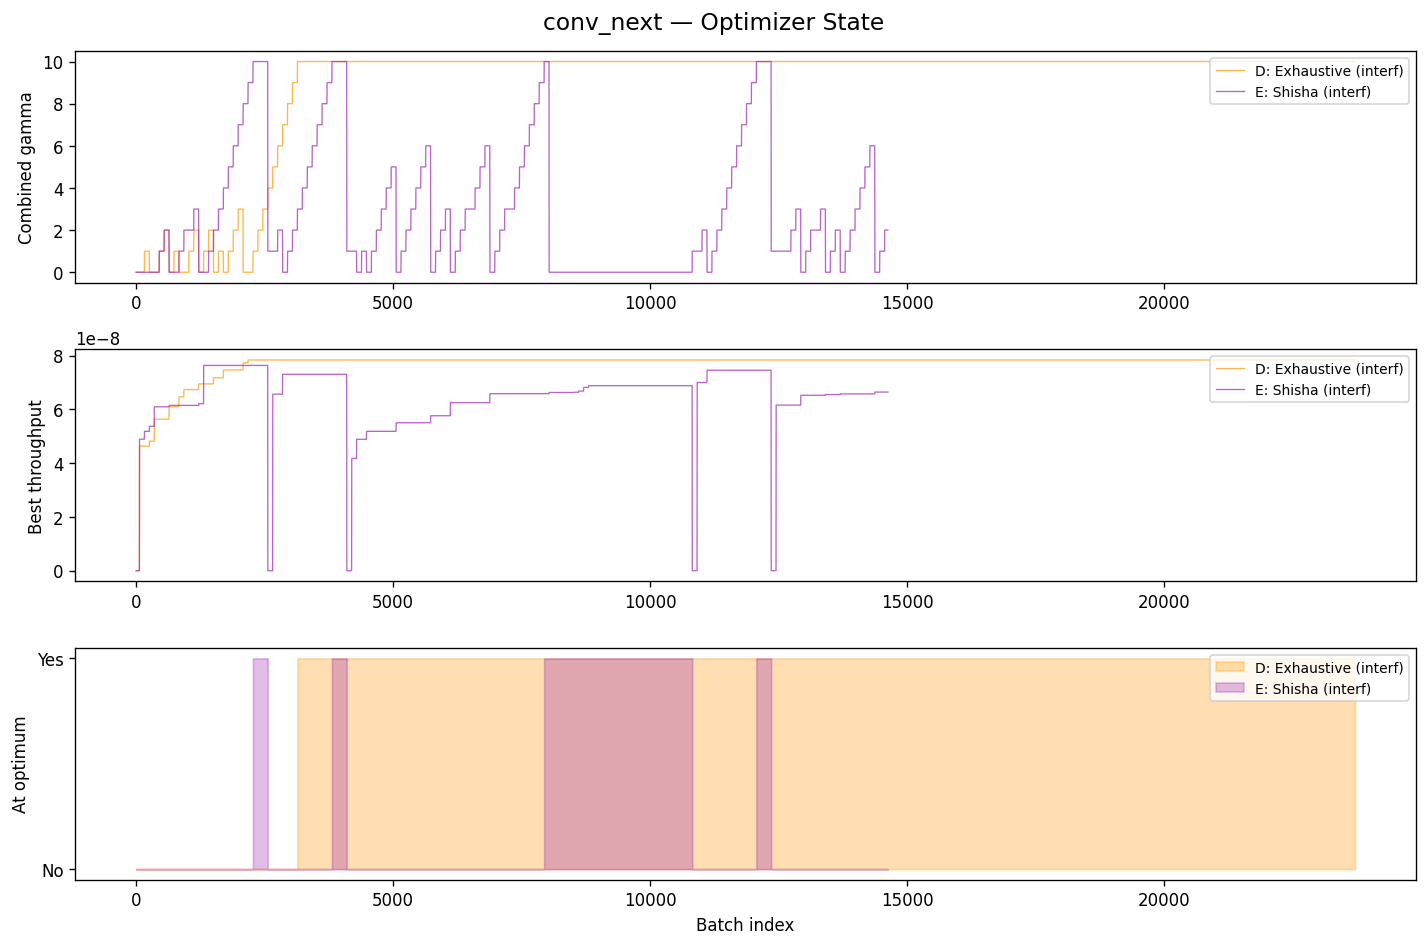

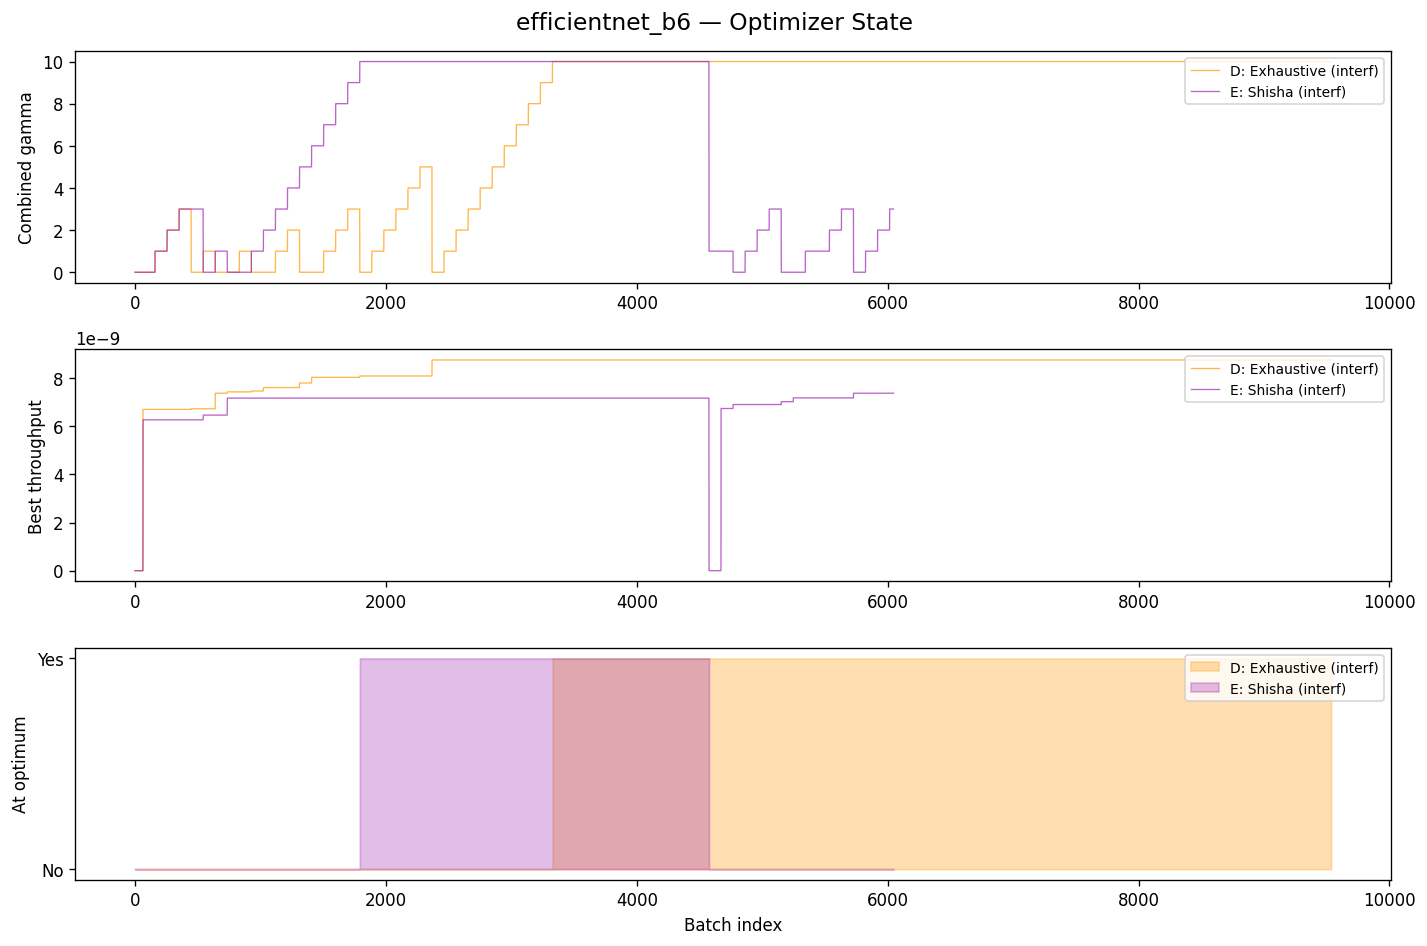

In [14]:
de_runs = {k: v for k, v in runs.items() if k in ("D", "E")}
if de_runs:
    for model in all_models:
        fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
        fig.suptitle(f"{model} — Optimizer State", fontsize=14)

        for run_id, data in sorted(de_runs.items()):
            result = data.get("results", {}).get(model)
            if result is None:
                continue
            batches = result.get("batches", [])
            info = RUN_INFO.get(run_id, {})
            color = info.get("color", "gray")
            label = f"{run_id}: {info.get('label', '?')}"

            deep_gamma = [b.get("rebalance", {}).get("deep_gamma") for b in batches]
            sibling_gamma = [b.get("rebalance", {}).get("sibling_gamma") for b in batches]
            best_tp = [b.get("rebalance", {}).get("best_throughput") for b in batches]

            if not any(v is not None for v in deep_gamma):
                continue

            opt_kwargs = data.get("meta", {}).get("optimizer_kwargs", {})
            deep_alpha = opt_kwargs.get("deep_alpha", 5)

            combined = [
                (d or 0) + (s or 0) * deep_alpha
                if d is not None and s is not None else None
                for d, s in zip(deep_gamma, sibling_gamma)
            ]

            xs = range(len(batches))

            # Combined gamma
            axes[0].plot(xs, combined, color=color, alpha=0.7, label=label, linewidth=0.8)

            # Best throughput
            axes[1].plot(xs, best_tp, color=color, alpha=0.7, label=label, linewidth=0.8)

            # Optimum regions
            opt_flags = [b.get("rebalance", {}).get("at_optimum", False) for b in batches]
            axes[2].fill_between(xs, opt_flags, color=color, alpha=0.3, label=label, step="post")

        axes[0].set_ylabel("Combined gamma")
        axes[1].set_ylabel("Best throughput")
        axes[2].set_ylabel("At optimum")
        axes[2].set_xlabel("Batch index")
        axes[2].set_yticks([0, 1])
        axes[2].set_yticklabels(["No", "Yes"])

        for ax in axes:
            ax.legend(fontsize="small", loc="upper right")

        fig.tight_layout()
        plt.show()
else:
    print("Runs D and E not available")

## Rebalance Activity

In [17]:
print(f"{'Model':<20} {'Run':<8} {'Batches':>10} {'Rebalances':>12} {'At Optimum':>12} {'Rebal %':>10} {'Optimum %':>10}")
print("-" * 82)

for model in all_models:
    for run_id in run_ids:
        result = runs[run_id].get("results", {}).get(model)
        if result is None:
            continue
        batches = result.get("batches", [])
        timed = [b for b in batches if "timing" in b]
        n = len(timed)
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        rebal_pct = (rebalances / n * 100) if n > 0 else 0
        opt_pct = (at_optimum / n * 100) if n > 0 else 0
        info = RUN_INFO.get(run_id, {})
        print(f"{model:<20} {run_id:<8} {n:>10} {rebalances:>12} {at_optimum:>12} {rebal_pct:>9.1f}% {opt_pct:>9.1f}%")

Model                Run         Batches   Rebalances   At Optimum    Rebal %  Optimum %
----------------------------------------------------------------------------------
conv_next            A               100            0            0       0.0%       0.0%
conv_next            B              5000         1216         3848      24.3%      77.0%
conv_next            C             16192            0            0       0.0%       0.0%
conv_next            D             23712         1056        20576       4.5%      86.8%
conv_next            E             14624         3744         3744      25.6%      25.6%
efficientnet_b6      A               100            0            0       0.0%       0.0%
efficientnet_b6      B              5000         3136         1992      62.7%      39.8%
efficientnet_b6      C              5920            0            0       0.0%       0.0%
efficientnet_b6      D              9536         1120         6208      11.7%      65.1%
efficientnet_b6      E     